In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

RESULTS = Path('../results')
DETECTORS = ['mahal', 'gmm']
DOMAINS   = ['synthetic', 'lightbox', 'sunlamp']
DETECTOR_LABELS = {'mahal': 'Mahalanobis', 'gmm': 'GMM'}
DOMAIN_COLORS   = {'synthetic': '#4C72B0', 'lightbox': '#DD8452', 'sunlamp': '#55A868'}

def load(detector, domain):
    scores = np.load(RESULTS / f'anomaly_scores_{detector}_{domain}.npy')
    errors = pd.read_csv(RESULTS / f'per_image_errors_{domain}.csv')['speed_score'].values
    n = min(len(scores), len(errors))
    return scores[:n], errors[:n]


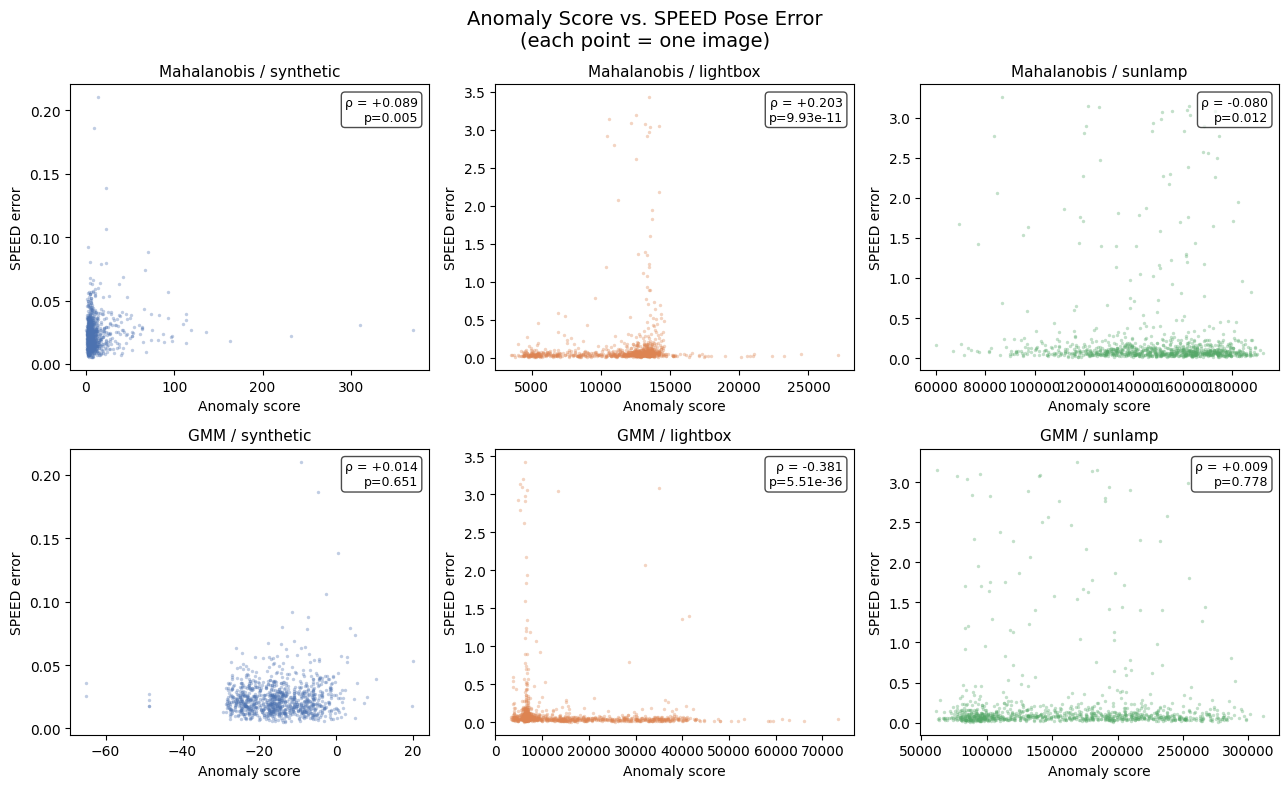

Saved → figures/score_error_correlation.png


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey=False)
fig.suptitle('Anomaly Score vs. SPEED Pose Error\n(each point = one image)', fontsize=14)

for row, det in enumerate(DETECTORS):
    for col, dom in enumerate(DOMAINS):
        ax = axes[row, col]
        scores, errors = load(det, dom)
        rho, pval = spearmanr(scores, errors)
        color = DOMAIN_COLORS[dom]

        ax.scatter(scores, errors, s=6, alpha=0.35, color=color, linewidths=0)
        ax.set_xlabel('Anomaly score', fontsize=10)
        ax.set_ylabel('SPEED error', fontsize=10)
        ax.set_title(f'{DETECTOR_LABELS[det]} / {dom}', fontsize=11)

        # annotate Spearman rho
        sign = '+' if rho >= 0 else ''
        pstr = f'p={pval:.2e}' if pval < 0.001 else f'p={pval:.3f}'
        ax.text(0.97, 0.96, f'ρ = {sign}{rho:.3f}\n{pstr}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.savefig('../figures/score_error_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/score_error_correlation.png')


In [3]:
# Summary table of Spearman ρ across all combinations
rows = []
for det in DETECTORS:
    for dom in DOMAINS:
        scores, errors = load(det, dom)
        rho, pval = spearmanr(scores, errors)
        rows.append({'detector': DETECTOR_LABELS[det], 'domain': dom,
                     'spearman_rho': round(rho, 3), 'p_value': round(pval, 4),
                     'n': len(scores)})

df = pd.DataFrame(rows)
print(df.to_string(index=False))


   detector    domain  spearman_rho  p_value    n
Mahalanobis synthetic         0.089   0.0048 1001
Mahalanobis  lightbox         0.203   0.0000 1001
Mahalanobis   sunlamp        -0.080   0.0118  999
        GMM synthetic         0.014   0.6512 1001
        GMM  lightbox        -0.381   0.0000 1001
        GMM   sunlamp         0.009   0.7780  999
